# 05 - Player segmentation (exploratory)

Do players form natural groups, and do those groups differ in market value?
This is **exploratory**. If K-means gives no clean, interpretable groups, that is
a valid result and rule-based segments are used instead.

Terminology: groups made by the algorithm are **K-means clusters**. Groups I
define by explicit rules are **segments**; they are never called clusters.

Design choices:
- Attackers only. Goals and assists describe attackers best; there are no
  role-specific statistics for defenders or goalkeepers (section 8).
- Only rows with at least 450 minutes (per-90 rates are unstable below that).
- Clustering uses profile variables only: age, total minutes, goals/90, assists/90.
  Goals + assists per 90 is left out because it is the sum of two included
  variables. **Market value is not a clustering input**; it is the outcome we
  compare across groups afterwards.
- Per-90 rates are winsorised at the 99th percentile, then all four features are
  standardised (K-means uses Euclidean distance).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, adjusted_rand_score
from src.data import *
from src.plots import *
from src.segments import *

FIG = ROOT / "figures" / "final"
def save(fig, name): fig.savefig(FIG / name, dpi=150, bbox_inches="tight"); plt.show()

df = load_player_season()
att = eligible_attackers(df)
print(f"{len(att):,} eligible attacker player-seasons")
att[FEATURES].describe().round(2)

6,095 eligible attacker player-seasons


,age,total_minutes,goals_per_90,assists_per_90
count,6095.0,6095.00,6095.00,6095.00
mean,25.9,1449.20,0.29,0.16
std,4.1,681.35,0.21,0.13
min,15.7,450.00,0.00,0.00
25%,22.8,876.50,0.14,0.07
50%,25.5,1356.00,0.26,0.14
75%,28.7,1932.00,0.40,0.23
max,41.0,3417.00,1.50,1.00


In [2]:
print("Spearman correlation between the clustering features:")
att[FEATURES].corr(method="spearman").round(2)

Spearman correlation between the clustering features:


,age,total_minutes,goals_per_90,assists_per_90
age,1.00,0.10,0.06,-0.04
total_minutes,0.10,1.00,0.23,0.15
goals_per_90,0.06,0.23,1.00,0.09
assists_per_90,-0.04,0.15,0.09,1.00


The four features are only weakly correlated, so none is redundant.

## 1. Choosing k (2 to 6)

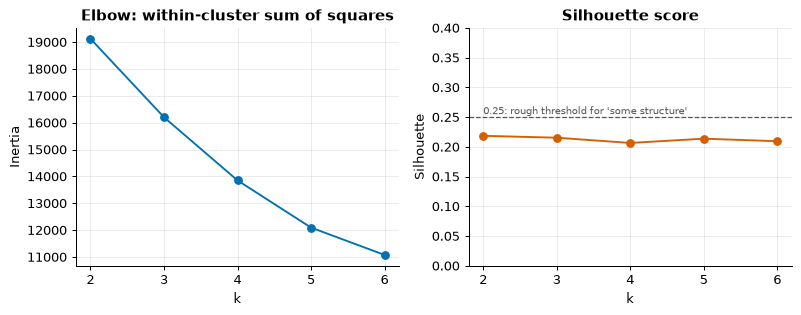

,inertia,silhouette
k,,
2,19125.0,0.219
3,16201.0,0.215
4,13850.0,0.207
5,12093.0,0.214
6,11075.0,0.209


In [3]:
Z = scale_features(att)
ks = list(range(2, 7)); inertia, sil = [], []
for k in ks:
    km = kmeans_fit(Z, k)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Z, km.labels_, sample_size=4000, random_state=SEED))
save(fig_k_selection(ks, inertia, sil), "11_kmeans_k_selection.png")
pd.DataFrame({"k": ks, "inertia": np.round(inertia), "silhouette": np.round(sil, 3)}).set_index("k")

**Reading:** there is no elbow (inertia falls smoothly) and the silhouette is
about 0.21 for every k, below the usual 0.25 rule-of-thumb for "some structure".
The metrics cannot pick k. I use **k = 4** on interpretability: it gives four
recognisable profiles (section 2) without over-splitting. This is a judgement,
not something the metrics support.

In [4]:
# Stability: same data, 10 different random starts, compared to the seed-0 solution.
base = kmeans_fit(Z, K).labels_
aris = [adjusted_rand_score(base, kmeans_fit(Z, K, seed=s).labels_) for s in range(1, 11)]
print(f"adjusted Rand index vs seed 0 (1 = identical): min {min(aris):.2f}, median {np.median(aris):.2f}")
# Stability under resampling: refit on random 80% subsets and compare on the shared rows.
rng = np.random.default_rng(0); boot = []
for _ in range(10):
    idx = np.sort(rng.choice(len(Z), int(0.8 * len(Z)), replace=False))
    boot.append(adjusted_rand_score(base[idx], kmeans_fit(Z[idx], K).labels_))
print(f"adjusted Rand index, 80% subsamples: min {min(boot):.2f}, median {np.median(boot):.2f}")

adjusted Rand index vs seed 0 (1 = identical): min 0.92, median 0.97


adjusted Rand index, 80% subsamples: min 0.89, median 0.92


Adjusted Rand index near 1 means the k = 4 solution is a reproducible
partition (about 0.9 or higher here). That is separate from the groups being
well separated: a stable slicing of a continuum can still be arbitrary at its
boundaries, which the low silhouette suggests.

## 2. The four K-means clusters

In [5]:
g = attacker_groups(df)
prof = (g.groupby("kmeans_group").agg(n=("age", "size"), median_age=("age", "median"), median_minutes=("total_minutes", "median"),
        goals_per_90=("goals_per_90", "median"), assists_per_90=("assists_per_90", "median"),
        median_value_eur=(MV, "median"))
    .sort_values("median_value_eur", ascending=False).round(2))
prof

,n,median_age,median_minutes,goals_per_90,assists_per_90,median_value_eur
kmeans_group,,,,,,
Regular high-minute starters,1576,25.90,2308.0,0.37,0.15,8000000.0
Creative attackers,1018,24.60,1234.5,0.28,0.35,5000000.0
"Younger, lower output",2046,23.05,1029.5,0.18,0.10,1500000.0
"Older, fewer minutes",1455,30.00,1124.0,0.23,0.10,1000000.0


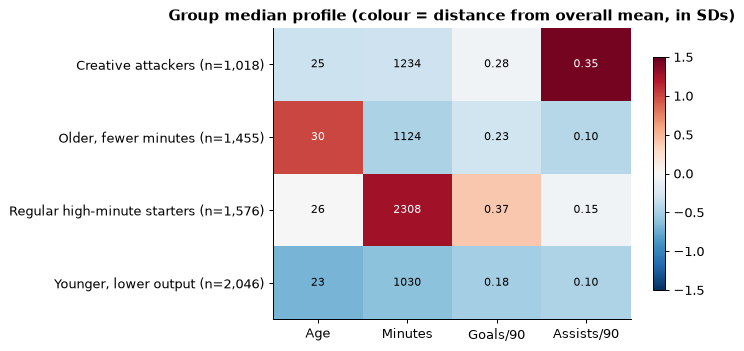

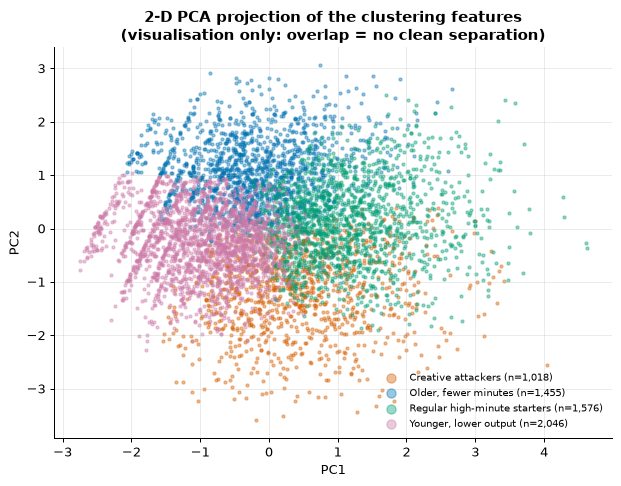

In [6]:
save(fig_group_heatmap(g, "kmeans_group", FEATURES), "12_kmeans_profiles.png")
save(fig_pca(g, "kmeans_group"), "13_kmeans_pca.png")

**Cluster descriptions** (names are descriptive labels from the median
profile, chosen by rule from the largest median in each feature):
- *Regular high-minute starters*: most minutes (median about 2,300), goals/90 highest.
- *Creative attackers*: assists/90 highest (about 0.35), moderate minutes.
- *Younger, lower output*: youngest (median about 23), low goals and assists, fewer minutes.
- *Older, fewer minutes*: oldest (median 30), low output and fewer minutes.

The PCA plot is only a 2-D drawing of the four features. The clusters overlap
heavily; it does not show that the clusters are real.

## 3. Market value across the clusters

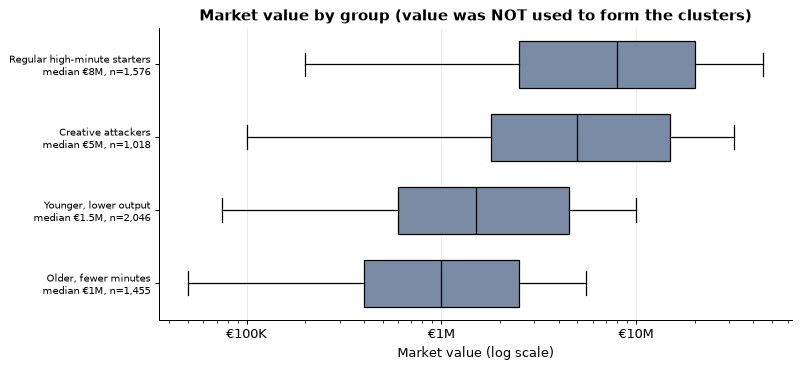

eta squared of log value by K-means cluster: 0.230
eta squared of log value by league (same rows): 0.430
eta squared of log value by age group (same rows): 0.056


In [7]:
save(fig_value_by_group(g, "kmeans_group"), "14_kmeans_value.png")
from src.plots import _eta_sq
print(f"eta squared of log value by K-means cluster: {_eta_sq(g, 'kmeans_group'):.3f}")
print(f"eta squared of log value by league (same rows): {_eta_sq(g, 'competition'):.3f}")
print(f"eta squared of log value by age group (same rows): {_eta_sq(g, 'age_group'):.3f}")

**Reading:** the clusters differ clearly in median value (about €1M to €8M), but
the value distributions overlap a lot, and league alone separates values more
than the clusters do. The starters cluster is highest largely because it is the
high-minutes group, and minutes are already known to be associated with value
(and go both ways). Cluster membership is a description of profile, not a cause
of value.

## 4. Representative players

In [8]:
Zg = pd.DataFrame(scale_features(g), index=g.index, columns=FEATURES)
rows = []
for name, s in g.groupby("kmeans_group"):
    centre = Zg.loc[s.index].mean()
    d = ((Zg.loc[s.index] - centre) ** 2).sum(axis=1).nsmallest(3).index
    rows += [g.loc[i, ["kmeans_group", "player_name", "season", "club", "age", "total_minutes", "goals_per_90", "assists_per_90", MV]] for i in d]
pd.DataFrame(rows).round(2).reset_index(drop=True)

,kmeans_group,player_name,season,club,age,total_minutes,goals_per_90,assists_per_90,market_value_in_eur
0,Creative attackers,Kelechi Iheanacho,2021,Leicester City,24.8,1260,0.29,0.36,20000000.0
1,Creative attackers,Boulaye Dia,2021,Villarreal CF,24.7,1268,0.35,0.35,12000000.0
2,Creative attackers,Nuno Moreira,2024,Casa Pia AC,25.1,1502,0.30,0.36,3000000.0
3,"Older, fewer minutes",Reziuan Mirzov,2024,FC Khimki (-2025),31.1,1117,0.24,0.08,500000.0
4,"Older, fewer minutes",Sebastian Andersson,2021,1.FC Köln,30.0,1256,0.21,0.07,2000000.0
5,"Older, fewer minutes",Frederik Gytkjaer,2022,Lyngby Boldklub,29.4,1025,0.26,0.09,300000.0
6,Regular high-minute starters,Grejohn Kyei,2022,Clermont Foot 63,27.0,2242,0.40,0.16,2500000.0
7,Regular high-minute starters,Oleksiy Gutsulyak,2024,FK Polissya Zhytomyr,26.6,2449,0.40,0.15,3000000.0
8,Regular high-minute starters,Maksym Pryadun,2022,Metalist Kharkiv,25.5,2185,0.37,0.16,600000.0
9,"Younger, lower output",Georgiy Melkadze,2020,RFK Akhmat Grozny,23.3,1108,0.24,0.08,1200000.0


Closest three player-seasons to each cluster's centre; shown only to make the profiles concrete.

## 5. Did K-means create meaningful football groups?

**Partly, with caveats.** K-means splits attackers into four groups that read
sensibly (regular starters, creative, younger low-output, older/fewer minutes)
and the solution is reproducible across random starts. But the structure is weak:
the silhouette is about 0.21 for every k (no elbow, nothing selects k = 4), the
groups overlap in the PCA view, and the four features vary continuously rather
than in separate lumps. The right description is: *K-means partitioned a
continuum of attacker profiles into four interpretable slices based on the
selected variables*. It did not discover distinct types of footballer. The
groups are a convenient way to read the data and are not evidence of natural
categories.

## 6. Rule-based segments (for comparison)

Because the clusters are soft, the same attackers are also grouped with
explicit, transparent rules. These are **segments**, not clusters. Cut-offs come
from the actual distributions of eligible attackers.

In [9]:
t = segment_thresholds(att)
print(f"goals/90 upper quartile = {t['goals_q3']:.2f}; assists/90 upper quartile = {t['assists_q3']:.2f}")
seg = (g.groupby("domain_segment").agg(n=("age", "size"), median_age=("age", "median"), median_minutes=("total_minutes", "median"),
        goals_per_90=("goals_per_90", "median"), assists_per_90=("assists_per_90", "median"), median_value_eur=(MV, "median"))
    .sort_values("median_value_eur", ascending=False).round(2))
seg

goals/90 upper quartile = 0.40; assists/90 upper quartile = 0.23


,n,median_age,median_minutes,goals_per_90,assists_per_90,median_value_eur
domain_segment,,,,,,
High scorers,1524,25.8,1543.5,0.53,0.15,6000000.0
Creative attackers,1074,24.9,1314.0,0.21,0.31,4000000.0
Young (under 24),1235,21.9,1219.0,0.19,0.11,2000000.0
Prime age (24-28),1456,26.2,1310.5,0.19,0.10,1800000.0
Experienced (29+),806,31.0,1371.0,0.20,0.10,900000.0


Rules, applied in this order (each attacker gets exactly one segment):
1. **High scorers**: goals/90 in the top quartile (at or above the value printed above).
2. **Creative attackers**: not a high scorer, assists/90 in the top quartile.
3. Everyone else by age: **Young** (under 24), **Prime age** (24-28), **Experienced** (29+).

These cut-offs are practical choices. The order means a young player who scores a
lot is a "High scorer", not "Young".

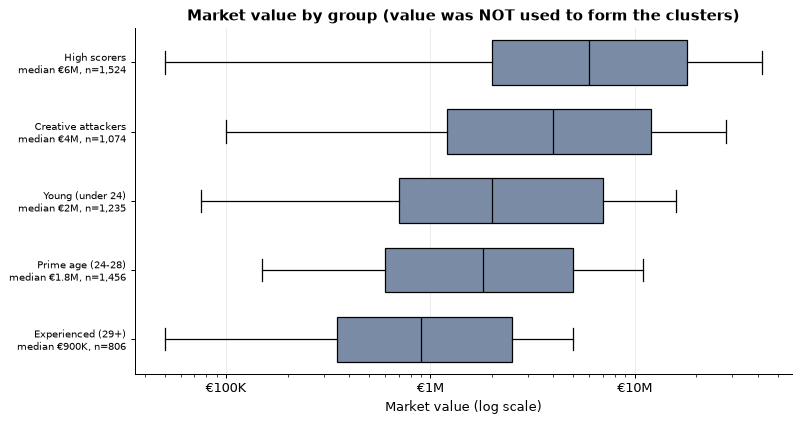

eta squared of log value by segment: 0.142  (K-means clusters: 0.230)


In [10]:
save(fig_value_by_group(g, "domain_segment"), "15_segments_value.png")
print(f"eta squared of log value by segment: {_eta_sq(g, 'domain_segment'):.3f}  (K-means clusters: {_eta_sq(g, 'kmeans_group'):.3f})")

**Reading:** high scorers and creative attackers have the highest median values;
experienced attackers the lowest. Segments are easier to explain than clusters,
but capture less of the variation in value (eta squared 0.14 vs 0.23). Because segment boundaries are
imposed, their sizes reflect my cut-offs, not any natural grouping.

## 7. Midfielders: same test, no forced result

In [11]:
mid = df[(df.position == "Midfield") & df.analysis_minutes_eligible]
Zm = scale_features(mid)
res = []
for k in range(2, 7):
    km = kmeans_fit(Zm, k)
    res.append((k, round(km.inertia_), round(silhouette_score(Zm, km.labels_, sample_size=4000, random_state=SEED), 3)))
print(f"{len(mid):,} eligible midfielders (goals/90 and assists/90 are weaker descriptors for midfielders)")
pd.DataFrame(res, columns=["k", "inertia", "silhouette"]).set_index("k")

6,876 eligible midfielders (goals/90 and assists/90 are weaker descriptors for midfielders)


,inertia,silhouette
k,,
2,21203,0.264
3,17308,0.220
4,14495,0.229
5,12793,0.238
6,11823,0.211


The midfielder silhouettes (0.21 to 0.26) are similarly weak. Goals and assists do not
capture what most midfielders do (passing, ball winning, pressing), so a
midfielder clustering on these four variables would not be football-meaningful.
I do not build a midfielder segmentation.

## 8. Defenders and goalkeepers

Not attempted. Defenders need tackles, interceptions, aerial duels and blocks;
goalkeepers need saves, save percentage and post-shot xG. The dataset contains
none of them, and goals/assists say very little about these roles. Clustering
them on age and minutes alone would only re-describe playing time.

## Conclusion

- K-means (k = 4, attackers, four profile variables, market value excluded)
  produced four readable but overlapping groups. Structure is weak (silhouette
  about 0.21 at every k); k = 4 was chosen for interpretability.
- Clusters differ in median value mostly through minutes and age, both already
  known associations. League separates values more than the clusters.
- Rule-based segments (high scorers, creative, young, prime, experienced) are
  simpler to explain (but capture less value variation, eta squared 0.14 vs 0.23)
  and are shown alongside, clearly labelled as segments.
- Midfielders, defenders and goalkeepers are not segmented for lack of suitable
  variables.